In [2]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import sys
import os

from sklearn.model_selection import train_test_split

project_root = os.path.abspath("..")   # Go up one level to CustomerRetentionAI
sys.path.insert(0, project_root)

from src.preprocessing import create_preprocessor

In [3]:
final_model = joblib.load("../models/final_model.pkl")

In [4]:
df = pd.read_csv("../data/processed/feature_engineered.csv")

X = df.drop("Churn", axis=1)
y = df["Churn"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    random_state=42,
    test_size=0.2
)

In [6]:
X_test_processed = final_model.named_steps["preprocessor"].transform(X_test)

In [7]:
feature_names = final_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# SHAP explainer

In [8]:
classifier = final_model.named_steps["classifier"]

explainer = shap.LinearExplainer(
    classifier,
    X_test_processed
)

shap_values = explainer.shap_values(X_test_processed)

Background dataset has 1407 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1407 when initializing the masker.


# Global Feature importance

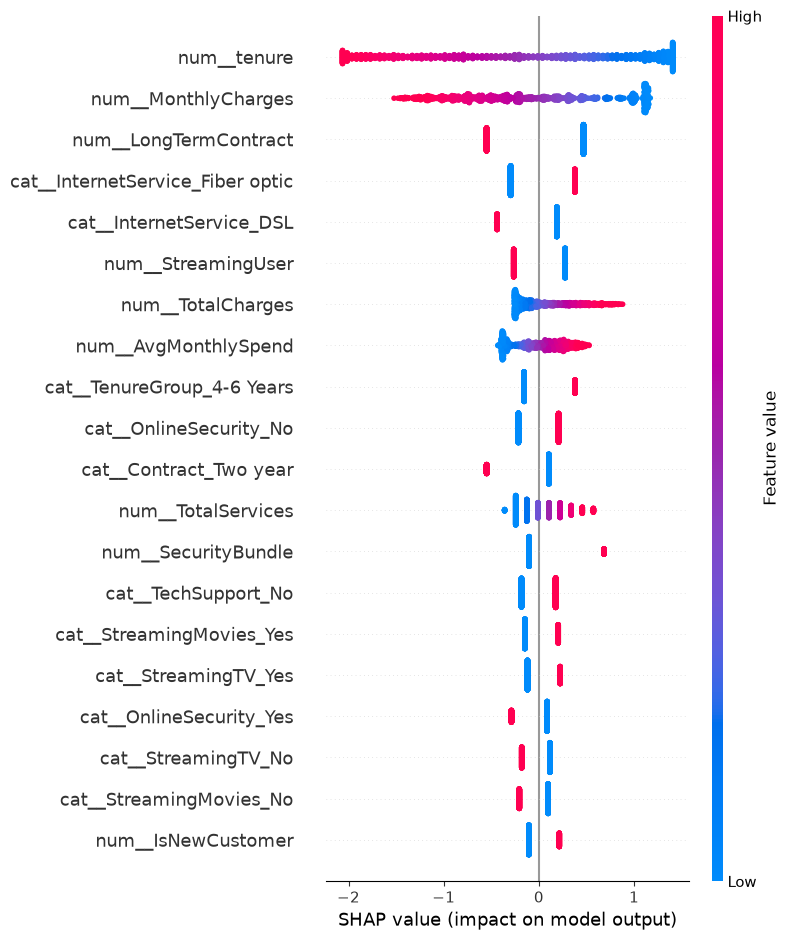

In [9]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

# SHAP Bar plot

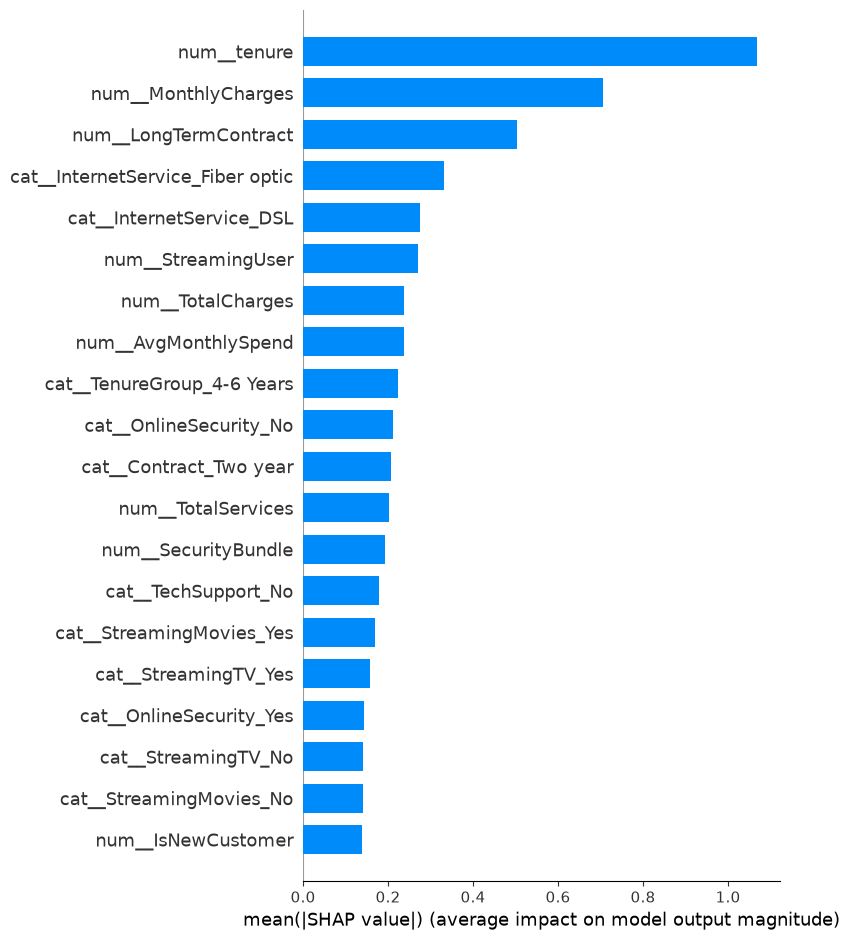

In [10]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type="bar"
)

# Dependence Plots

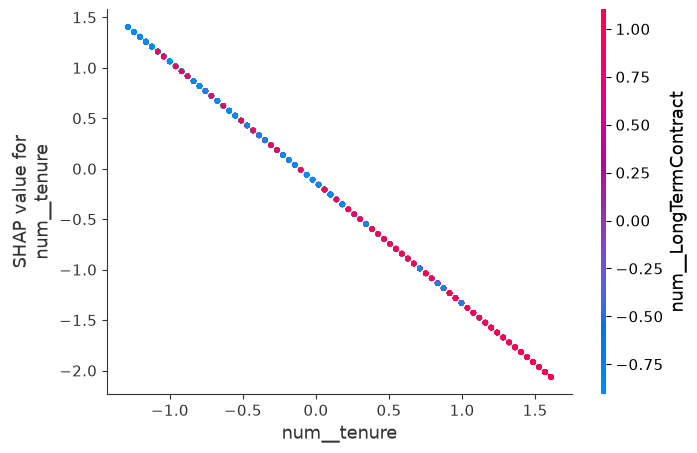

In [11]:
shap.dependence_plot(
    "num__tenure",
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

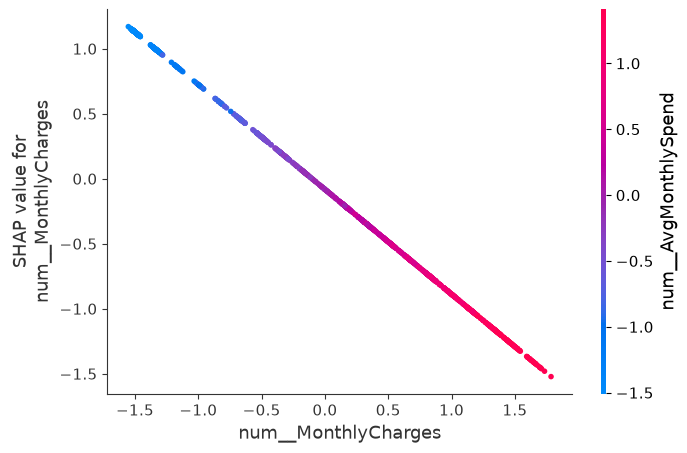

In [13]:
shap.dependence_plot(
    "num__MonthlyCharges",
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

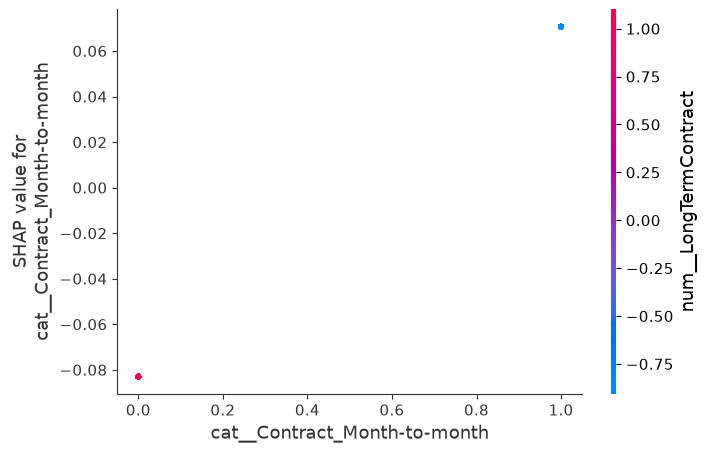

In [14]:
shap.dependence_plot(
    "cat__Contract_Month-to-month",
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

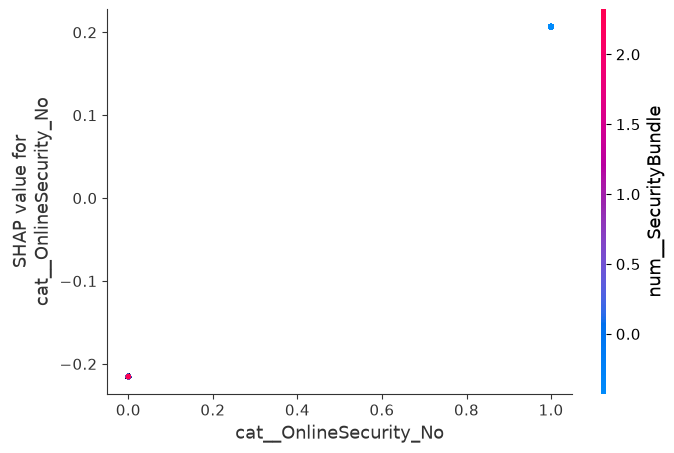

In [17]:
shap.dependence_plot(
    "cat__OnlineSecurity_No",
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

# Individual customer

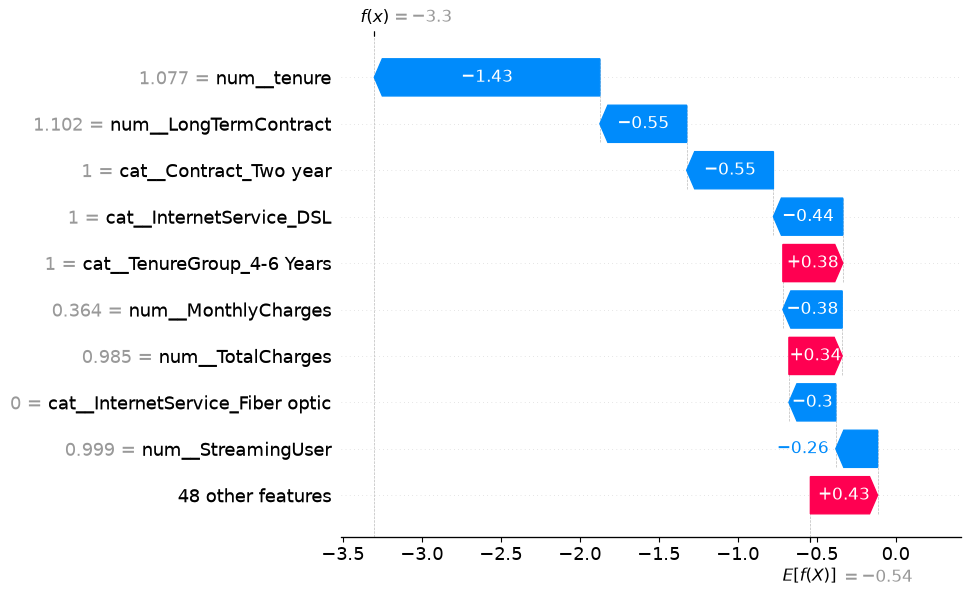

In [18]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test_processed[0],
        feature_names=feature_names
    )
)

# Business Insights

The SHAP analysis suggests several practical customer retention strategies:

Focus retention campaigns on new customers, as they are at the highest risk of churn.
Review pricing strategies for customers with high monthly charges, potentially offering discounts or bundled plans.
Encourage migration to long-term contracts, which substantially reduce churn risk.
Promote value-added services such as Online Security and Tech Support to increase customer engagement and reduce switching behavior.
Closely monitor Fiber Optic customers, who appear to exhibit elevated churn risk despite using premium services.

# Summary

Objective

Interpret the predictions of the final customer churn model using SHAP and identify the key drivers influencing customer churn.

Key Findings
SHAP provided transparent explanations for individual predictions and overall model behavior.
Tenure was identified as the most influential feature, with shorter-tenure customers exhibiting a substantially higher risk of churn.
Monthly Charges and contract duration were also major contributors to churn predictions.
Customers with additional services such as Online Security and Tech Support generally showed lower churn risk.
Internet service type, particularly Fiber Optic, had a noticeable influence on the model's predictions.
Conclusion

The SHAP analysis demonstrates that the final Logistic Regression model is not only accurate but also highly interpretable. The explanations align with intuitive business reasoning, increasing confidence in the model's predictions. These insights can help customer retention teams prioritize high-risk customers and design targeted interventions such as onboarding programs, pricing adjustments, long-term contract incentives, and bundled service offerings.